In [59]:
!pip install pandas numpy requests beautifulsoup4 lxml hmmlearn matplotlib scikit-learn

Start with 118th congress, 1st session

In [60]:
import pandas as pd
import glob
import os
import re

def load_vote_file(file_path):
    df = pd.read_csv(
        file_path,
        skiprows=5,
        header=None,
        usecols=[0, 1, 2, 3],
        names=["Representative", "Party", "State", "Vote"]
    )

    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()

    session = os.path.basename(os.path.dirname(file_path))
    df["Session"] = session

    match = re.search(r"_(\d+)\.csv$", os.path.basename(file_path))
    df["Roll_Call"] = int(match.group(1)) if match else os.path.basename(file_path)

    df["Vote_ID"] = session + "_" + df["Roll_Call"].astype(str)

    vote_map = {
        "Yea": 1,
        "Nay": 0,
        "Present": 2,
        "Not Voting": 2
    }

    df["Vote_Code"] = df["Vote"].map(vote_map)

    return df

files = glob.glob("data/raw/*/votes_house_*.csv")

print("Files found:", len(files))
print(files[:5])

all_votes = pd.concat(
    [load_vote_file(f) for f in files],
    ignore_index=True
)

display(all_votes.head())
print(all_votes.shape)

Files found: 408
['data/raw/117-s2/votes_house_117_2_525.csv', 'data/raw/117-s2/votes_house_117_2_531.csv', 'data/raw/117-s2/votes_house_117_2_519.csv', 'data/raw/117-s2/votes_house_117_2_518.csv', 'data/raw/117-s2/votes_house_117_2_530.csv']


,Representative,Party,State,Vote,Session,Roll_Call,Vote_ID,Vote_Code
0,"Adams, Alma S. [D-NC]",Democratic,North Carolina,Yea,117-s2,525,117-s2_525,1.0
1,"Aderholt, Robert B. [R-AL]",Republican,Alabama,Nay,117-s2,525,117-s2_525,0.0
2,"Aguilar, Pete [D-CA]",Democratic,California,Yea,117-s2,525,117-s2_525,1.0
3,"Allen, Rick W. [R-GA]",Republican,Georgia,Nay,117-s2,525,117-s2_525,0.0
4,"Allred, Colin Z. [D-TX]",Democratic,Texas,Yea,117-s2,525,117-s2_525,1.0


(176237, 8)


CREATE THE HMM MATRIX

In [61]:
vote_matrix = all_votes.pivot_table(
    index="Representative",
    columns="Vote_ID",
    values="Vote_Code",
    aggfunc="first"
)

vote_matrix = vote_matrix.fillna(2).astype(int)

display(vote_matrix.head())
print(vote_matrix.shape)

Vote_ID,116-s1_651,116-s1_652,116-s1_653,116-s1_654,116-s1_655,116-s1_656,116-s1_657,116-s1_658,116-s1_659,116-s1_660,...,119-s2_183,119-s2_184,119-s2_185,119-s2_186,119-s2_187,119-s2_188,119-s2_189,119-s2_190,119-s2_191,119-s2_votes_house_119_2_170-2.csv
Representative,,,,,,,,,,,,,,,,,,,,,
"Abraham, Ralph Lee [R-LA]",0,0,2,2,1,1,0,0,1,2,...,2,2,2,2,2,2,2,2,2,2
"Adams, Alma S. [D-NC]",1,1,2,2,1,1,1,1,1,2,...,1,2,0,2,1,0,1,0,0,1
"Aderholt, Robert B. [R-AL]",0,0,2,2,2,2,2,2,2,2,...,0,2,1,2,0,1,0,1,1,0
"Aguilar, Pete [D-CA]",1,1,2,2,1,1,1,1,1,2,...,1,2,0,2,1,0,1,0,0,1
"Alford, Mark [R-MO]",2,2,2,2,2,2,2,2,2,2,...,0,2,1,2,0,1,0,1,1,0


(689, 408)


In [62]:
!pip install hmmlearn

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.metrics import accuracy_score

party labels created


In [64]:
rep_info = all_votes.groupby("Representative")[["Party", "State"]].first()

common_reps = vote_matrix.index.intersection(rep_info.index)

vote_matrix = vote_matrix.loc[common_reps]
rep_info = rep_info.loc[common_reps]

vote_matrix = vote_matrix.fillna(2).astype(int)

display(vote_matrix.head())
display(rep_info.head())

print("vote_matrix shape:", vote_matrix.shape)
print("rep_info shape:", rep_info.shape)

Vote_ID,116-s1_651,116-s1_652,116-s1_653,116-s1_654,116-s1_655,116-s1_656,116-s1_657,116-s1_658,116-s1_659,116-s1_660,...,119-s2_183,119-s2_184,119-s2_185,119-s2_186,119-s2_187,119-s2_188,119-s2_189,119-s2_190,119-s2_191,119-s2_votes_house_119_2_170-2.csv
Representative,,,,,,,,,,,,,,,,,,,,,
"Abraham, Ralph Lee [R-LA]",0,0,2,2,1,1,0,0,1,2,...,2,2,2,2,2,2,2,2,2,2
"Adams, Alma S. [D-NC]",1,1,2,2,1,1,1,1,1,2,...,1,2,0,2,1,0,1,0,0,1
"Aderholt, Robert B. [R-AL]",0,0,2,2,2,2,2,2,2,2,...,0,2,1,2,0,1,0,1,1,0
"Aguilar, Pete [D-CA]",1,1,2,2,1,1,1,1,1,2,...,1,2,0,2,1,0,1,0,0,1
"Alford, Mark [R-MO]",2,2,2,2,2,2,2,2,2,2,...,0,2,1,2,0,1,0,1,1,0


,Party,State
Representative,,
"Abraham, Ralph Lee [R-LA]",Republican,Louisiana
"Adams, Alma S. [D-NC]",Democratic,North Carolina
"Aderholt, Robert B. [R-AL]",Republican,Alabama
"Aguilar, Pete [D-CA]",Democratic,California
"Alford, Mark [R-MO]",Republican,Missouri


vote_matrix shape: (689, 408)
rep_info shape: (689, 2)


train hmm model now

In [65]:
n_states = 4

X = vote_matrix.values.reshape(-1, 1)
lengths = [vote_matrix.shape[1]] * vote_matrix.shape[0]

model = hmm.CategoricalHMM(
    n_components=n_states,
    n_features=3,
    n_iter=300,
    random_state=42,
    init_params="ste"
)

model.fit(X, lengths)

hidden_states = model.predict(X, lengths)

hidden_matrix = pd.DataFrame(
    hidden_states.reshape(vote_matrix.shape),
    index=vote_matrix.index,
    columns=vote_matrix.columns
)

display(hidden_matrix.head())

Vote_ID,116-s1_651,116-s1_652,116-s1_653,116-s1_654,116-s1_655,116-s1_656,116-s1_657,116-s1_658,116-s1_659,116-s1_660,...,119-s2_183,119-s2_184,119-s2_185,119-s2_186,119-s2_187,119-s2_188,119-s2_189,119-s2_190,119-s2_191,119-s2_votes_house_119_2_170-2.csv
Representative,,,,,,,,,,,,,,,,,,,,,
"Abraham, Ralph Lee [R-LA]",3,3,0,0,3,3,3,3,3,0,...,2,2,2,2,2,2,2,2,2,2
"Adams, Alma S. [D-NC]",3,3,0,0,3,3,3,3,3,0,...,3,3,3,3,3,3,3,3,3,3
"Aderholt, Robert B. [R-AL]",3,3,0,0,0,0,0,0,0,0,...,3,3,3,3,3,3,3,3,3,3
"Aguilar, Pete [D-CA]",3,3,0,0,3,3,3,3,3,0,...,3,3,3,3,3,3,3,3,3,3
"Alford, Mark [R-MO]",2,2,2,2,2,2,2,2,2,2,...,3,3,3,3,3,3,3,3,3,3


heatmap generated

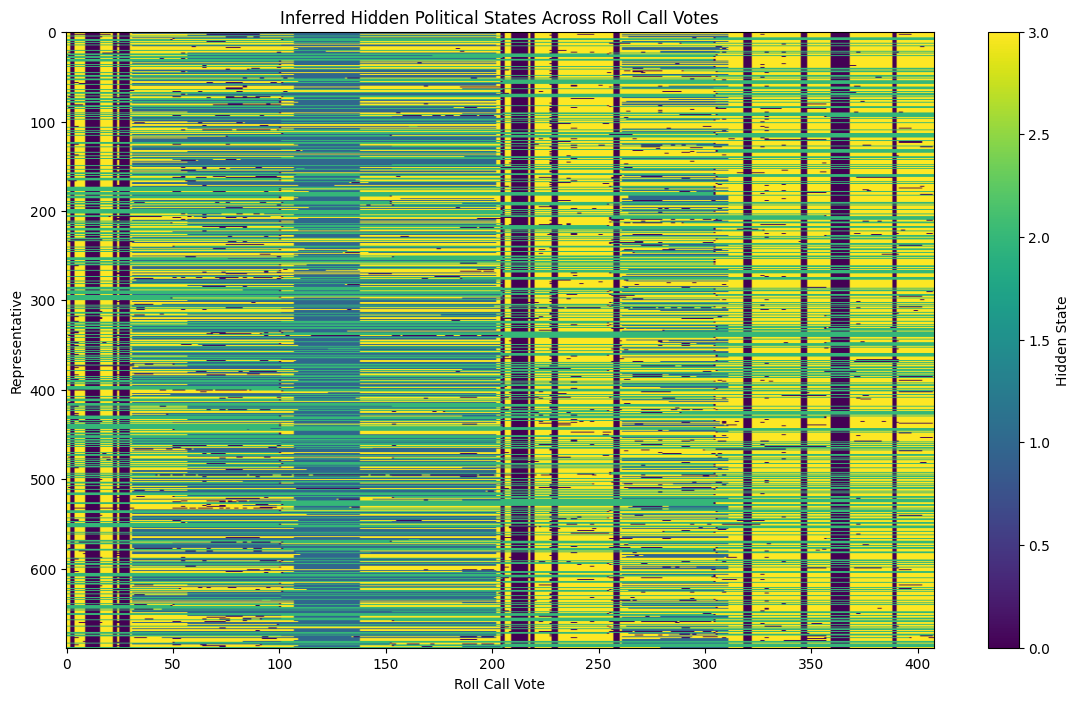

In [66]:
plt.figure(figsize=(14, 8))
plt.imshow(hidden_matrix.values, aspect="auto")
plt.colorbar(label="Hidden State")
plt.xlabel("Roll Call Vote")
plt.ylabel("Representative")
plt.title("Inferred Hidden Political States Across Roll Call Votes")
plt.show()

emission probabiltiies

,Nay,Yea,Present/Not Voting
0,3.127631e-52,6.002028e-20,1.000000
1,5.878294e-02,9.166189e-01,0.024598
2,4.098288e-73,6.859527e-22,1.000000
3,3.550229e-01,5.494392e-01,0.095538


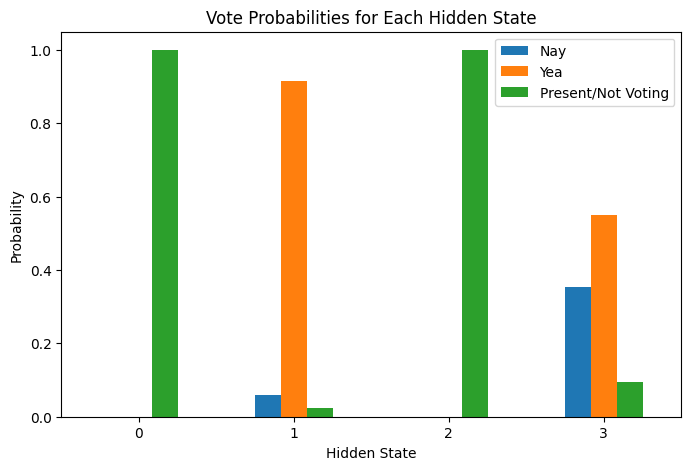

In [67]:
emissions = pd.DataFrame(
    model.emissionprob_,
    columns=["Nay", "Yea", "Present/Not Voting"]
)

display(emissions)

emissions.plot(kind="bar", figsize=(8,5))
plt.xlabel("Hidden State")
plt.ylabel("Probability")
plt.title("Vote Probabilities for Each Hidden State")
plt.xticks(rotation=0)
plt.show()

transition matrix

,0,1,2,3
0,0.715536,1.343478e-13,6.199040e-03,2.782650e-01
1,0.000119,9.790687e-01,2.501704e-03,1.831051e-02
2,0.002487,2.713660e-04,9.972413e-01,3.170249e-07
3,0.071848,9.429702e-03,1.965410e-07,9.187221e-01


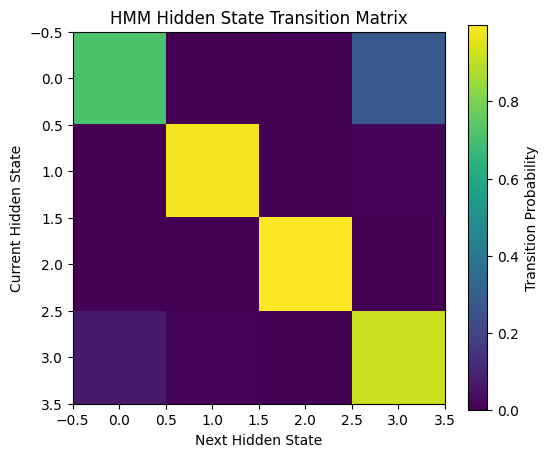

In [68]:
transitions = pd.DataFrame(model.transmat_)

display(transitions)

plt.figure(figsize=(6,5))
plt.imshow(model.transmat_)
plt.colorbar(label="Transition Probability")
plt.xlabel("Next Hidden State")
plt.ylabel("Current Hidden State")
plt.title("HMM Hidden State Transition Matrix")
plt.show()

compare diff numbers of hidden states

In [ ]:
state_results = []

for k in [2, 3, 4, 5, 6, 8, 10]:
    temp_model = hmm.CategoricalHMM(
        n_components=k,
        n_features=3,
        n_iter=300,
        random_state=42,
        init_params="ste"
    )
    
    temp_model.fit(X, lengths)
    log_likelihood = temp_model.score(X, lengths)
    
    state_results.append({
        "Hidden States": k,
        "Log Likelihood": log_likelihood,
        "Log Likelihood Per Vote": log_likelihood / len(X)
    })

state_results = pd.DataFrame(state_results)
display(state_results)

plt.figure(figsize=(8,5))
plt.plot(
    state_results["Hidden States"],
    state_results["Log Likelihood Per Vote"],
    marker="o"
)
plt.xlabel("Number of Hidden States")
plt.ylabel("Log Likelihood Per Vote")
plt.title("Model Fit as Number of Hidden States Changes")
plt.grid(True)
plt.show()

In [ ]:
predicted_votes = []

for state in hidden_states:
    predicted_vote = np.argmax(model.emissionprob_[state])
    predicted_votes.append(predicted_vote)

actual_votes = X.flatten()
accuracy = accuracy_score(actual_votes, predicted_votes)

print("Vote reconstruction accuracy:", accuracy)

Vote reconstruction accuracy: 0.8322095671981776


,Hidden States,Accuracy
0,2,0.715125
1,3,0.697585
2,4,0.832210
3,5,0.756219
4,6,0.879180
5,8,0.767335
6,10,0.805467


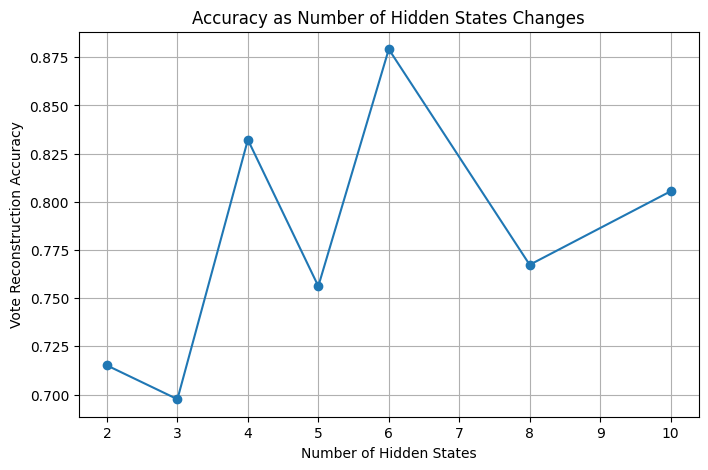

In [ ]:
accuracy_results = []

for k in [2, 3, 4, 5, 6, 8, 10]:
    temp_model = hmm.CategoricalHMM(
        n_components=k,
        n_features=3,
        n_iter=300,
        random_state=42,
        init_params="ste"
    )
    
    temp_model.fit(X, lengths)
    states = temp_model.predict(X, lengths)
    
    preds = [np.argmax(temp_model.emissionprob_[s]) for s in states]
    acc = accuracy_score(actual_votes, preds)
    
    accuracy_results.append({
        "Hidden States": k,
        "Accuracy": acc
    })

accuracy_results = pd.DataFrame(accuracy_results)
display(accuracy_results)

plt.figure(figsize=(8,5))
plt.plot(
    accuracy_results["Hidden States"],
    accuracy_results["Accuracy"],
    marker="o"
)
plt.xlabel("Number of Hidden States")
plt.ylabel("Vote Reconstruction Accuracy")
plt.title("Accuracy as Number of Hidden States Changes")
plt.grid(True)
plt.show()

Party,Democratic,Republican
Dominant Hidden State,,
0.0,206,216
1.0,3,3
3.0,6,5


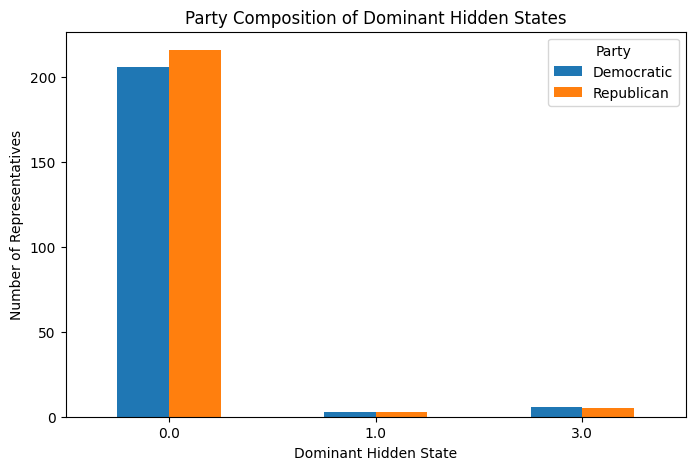

In [ ]:
rep_dominant_state = hidden_matrix.mode(axis=1)[0]

party_state_df = pd.DataFrame({
    "Party": rep_info.loc[rep_dominant_state.index, "Party"],
    "Dominant Hidden State": rep_dominant_state
})

party_state_counts = pd.crosstab(
    party_state_df["Dominant Hidden State"],
    party_state_df["Party"]
)

display(party_state_counts)

party_state_counts.plot(kind="bar", figsize=(8,5))
plt.xlabel("Dominant Hidden State")
plt.ylabel("Number of Representatives")
plt.title("Party Composition of Dominant Hidden States")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

EXPIERIMENT TABLE

In [ ]:
results = []

actual_votes = X.flatten()

for k in [2, 3, 4, 5, 6, 8, 10]:

    temp_model = hmm.CategoricalHMM(
        n_components=k,
        n_features=3,
        n_iter=300,
        random_state=42,
        init_params="ste"
    )

    temp_model.fit(X, lengths)

    hidden_states = temp_model.predict(X, lengths)

    predicted_votes = []

    for state in hidden_states:
        pred_vote = np.argmax(temp_model.emissionprob_[state])
        predicted_votes.append(pred_vote)

    accuracy = accuracy_score(actual_votes, predicted_votes)

    precision = precision_score(
        actual_votes,
        predicted_votes,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        actual_votes,
        predicted_votes,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        actual_votes,
        predicted_votes,
        average="weighted",
        zero_division=0
    )

    log_likelihood = temp_model.score(X, lengths)

    results.append({
        "Hidden States": k,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Log Likelihood Per Vote":
            log_likelihood / len(X)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Hidden States,Accuracy,Precision,Recall,F1 Score,Log Likelihood Per Vote
0,2,0.715125,0.670501,0.715125,0.660371,-0.928008
1,3,0.697585,0.664423,0.697585,0.643141,-0.919443
2,4,0.832210,0.720319,0.832210,0.766256,-0.883744
3,5,0.756219,0.651305,0.756219,0.694848,-0.888312
4,6,0.879180,0.896793,0.879180,0.876976,-0.818078
5,8,0.767335,0.690527,0.767335,0.709229,-0.815573
6,10,0.805467,0.854406,0.805467,0.784301,-0.747489


ACCURACY/F1 GRAPH

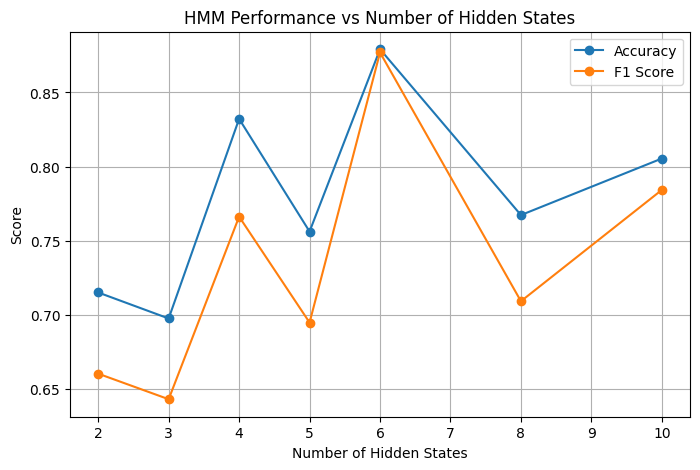

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Hidden States"],
    results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    results_df["Hidden States"],
    results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Number of Hidden States")
plt.ylabel("Score")
plt.title("HMM Performance vs Number of Hidden States")
plt.legend()
plt.grid(True)

plt.show()

LOG LIKELIHOOD GRAPH

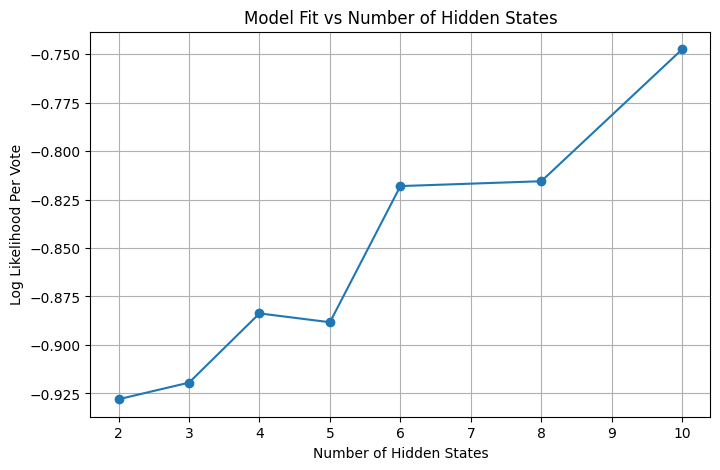

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Hidden States"],
    results_df["Log Likelihood Per Vote"],
    marker="o"
)

plt.xlabel("Number of Hidden States")
plt.ylabel("Log Likelihood Per Vote")

plt.title("Model Fit vs Number of Hidden States")

plt.grid(True)

plt.show()